Initiating RSI Factor Diagnostic...
Processing Snapshot: 2026-03-31

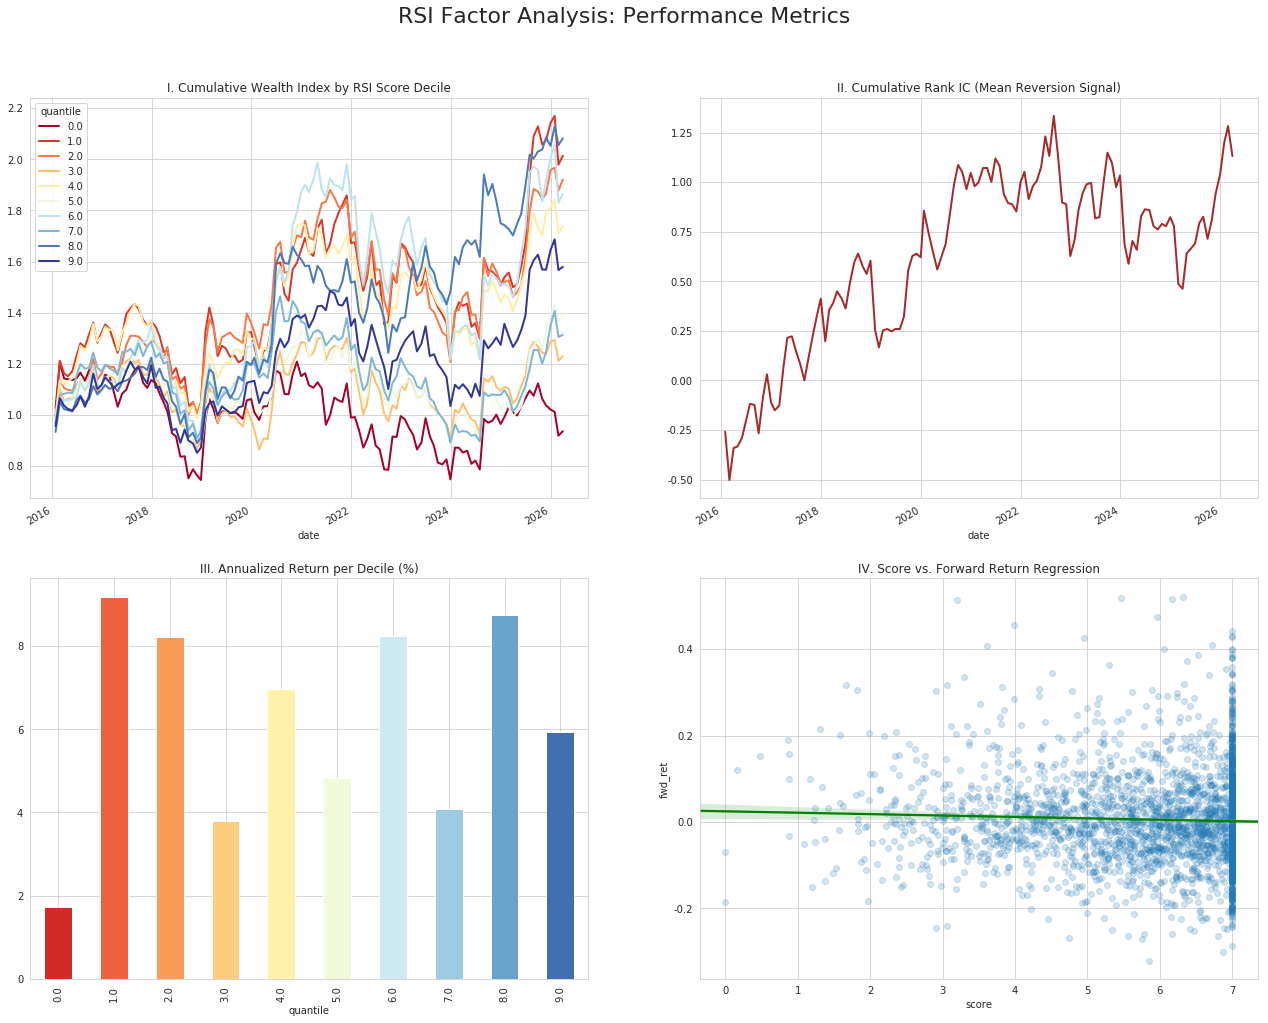

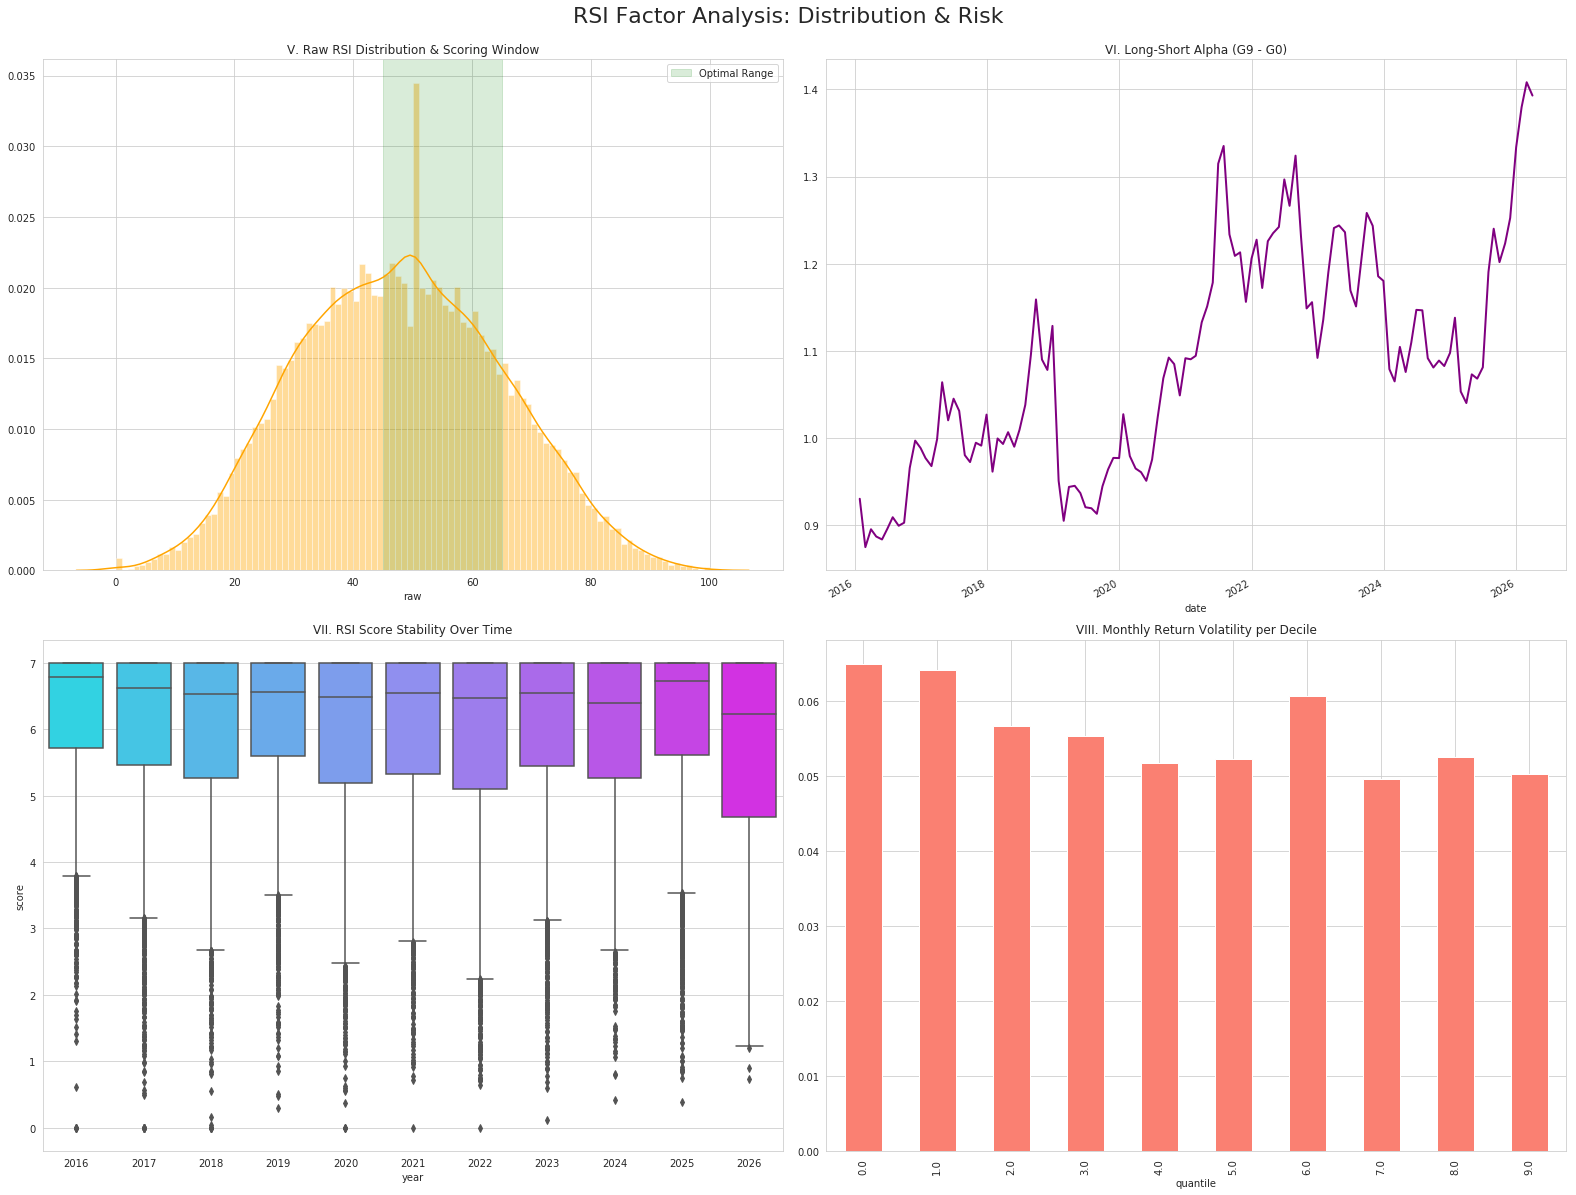


Average IC: 0.0092 | ICIR: 0.0765


In [1]:
'''
This factor is based on the "Relative Strength Index (RSI)" logic, 
a classic momentum oscillator that measures the speed and change of price movements.

The scoring mechanism aims to identify stocks within an "Optimal Strength Window." 
Typically, an RSI between 40 and 60 represents a stable trend, while extreme values 
(>70 or <30) suggest overbought or oversold conditions prone to reversals. 

By using calculate_range_score, we reward stocks that maintain healthy technical 
structure and penalize those exhibiting extreme speculative heat or structural weakness.
This diagnostic evaluates whether the RSI "Sweet Spot" effectively predicts 
next-month alpha in the 000300.XSHG universe.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jqdata import *
import warnings

# 1. Environment Configuration
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# 2. Core Scoring Logic
def calculate_range_score(value, optimal_range, max_score, reverse=False):
    low, high = optimal_range
    if reverse:
        if value <= low: return max_score
        elif value >= high: return max_score * 0.1
        else: return max_score * (1 - (value - low) / (high - low))
    else:
        if low <= value <= high: return max_score
        elif value < low:
            return max_score * (value / low) if low > 0 else max_score * 0.3
        else:
            # Penalize for overbought conditions (Mean Reversion Risk)
            return max_score * (high / value) if value > 0 else max_score * 0.3

# 3. Parameters and Backtest Engine
start_date, end_date = "2016-01-01", "2026-04-01"
all_days = get_trade_days(start_date, end_date)
ts_series = pd.to_datetime(pd.Series(all_days))
rebal_dates = ts_series.groupby([ts_series.dt.year, ts_series.dt.month]).last()
date_list = [d.strftime('%Y-%m-%d') for d in rebal_dates]

# Simulation Configuration
rsi_period = 14     # Standard RSI lookback
opt_range = (45, 65) # Target: Moderate strength, avoiding extreme overbought
weight = 7

dataset = []
print("Initiating RSI Factor Diagnostic...")

for i in range(len(date_list) - 1):
    t0, t1 = date_list[i], date_list[i+1]
    universe = get_index_stocks('000300.XSHG', date=t0)
    print("\rProcessing Snapshot: {}".format(t0), end="")
    
    # Fetch prices (need period + 1 for diff)
    prices = get_price(universe, end_date=t0, count=rsi_period+1, fields='close', panel=False)
    
    res = []
    for s in universe:
        s_p = prices[prices['code'] == s]['close']
        if len(s_p) < rsi_period: continue
        
        # Calculate RSI
        delta = s_p.diff().dropna()
        gain = delta.where(delta > 0, 0).rolling(window=rsi_period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=rsi_period).mean()
        
        # Avoid division by zero
        last_gain = gain.iloc[-1]
        last_loss = loss.iloc[-1]
        if last_loss == 0:
            current_rsi = 100 if last_gain > 0 else 50
        else:
            rs = last_gain / last_loss
            current_rsi = 100 - (100 / (1 + rs))
        
        score = calculate_range_score(current_rsi, opt_range, weight)
        res.append({'code': s, 'raw': current_rsi, 'score': score})
    
    if not res: continue
    
    df = pd.DataFrame(res)
    p0 = get_price(list(df['code']), end_date=t0, count=1, fields='close', panel=False).set_index('code')['close']
    p1 = get_price(list(df['code']), end_date=t1, count=1, fields='close', panel=False).set_index('code')['close']
    
    df['fwd_ret'] = df['code'].map((p1 / p0) - 1)
    df['date'] = pd.to_datetime(t0)
    dataset.append(df)

master_df = pd.concat(dataset, ignore_index=True).dropna()
master_df['year'] = master_df['date'].dt.year
master_df['quantile'] = master_df.groupby('date')['score'].transform(
    lambda x: pd.qcut(x.rank(method='first'), 10, labels=False)
)

# 4. Visualization (9-Plot System)
ic_ts = master_df.groupby('date').apply(lambda g: g['score'].corr(g['fwd_ret']))
q_ret = master_df.groupby(['date', 'quantile'])['fwd_ret'].mean().unstack()

# Plot Set 1
fig1, axes1 = plt.subplots(2, 2, figsize=(22, 18))
plt.suptitle('RSI Factor Analysis: Performance Metrics', fontsize=22, y=0.95)

(1 + q_ret).cumprod().plot(ax=axes1[0, 0], colormap='RdYlBu', lw=2)
axes1[0, 0].set_title("I. Cumulative Wealth Index by RSI Score Decile")

ic_ts.cumsum().plot(ax=axes1[0, 1], color='brown', lw=2)
axes1[0, 1].set_title("II. Cumulative Rank IC (Mean Reversion Signal)")

(q_ret.mean() * 12 * 100).plot(kind='bar', color=sns.color_palette("RdYlBu", 10), ax=axes1[1, 0])
axes1[1, 0].set_title("III. Annualized Return per Decile (%)")

sns.regplot(x='score', y='fwd_ret', data=master_df.sample(min(len(master_df), 3000)), 
            ax=axes1[1, 1], scatter_kws={'alpha':0.2}, line_kws={'color':'green'})
axes1[1, 1].set_title("IV. Score vs. Forward Return Regression")

# Plot Set 2
fig2, axes2 = plt.subplots(2, 2, figsize=(22, 18))
plt.suptitle('RSI Factor Analysis: Distribution & Risk', fontsize=22, y=0.95)



sns.distplot(master_df['raw'], bins=100, color='orange', ax=axes2[0, 0])
axes2[0, 0].axvspan(opt_range[0], opt_range[1], color='green', alpha=0.15, label='Optimal Range')
axes2[0, 0].set_title("V. Raw RSI Distribution & Scoring Window")
axes2[0, 0].legend()

(1 + (q_ret[9] - q_ret[0])).cumprod().plot(ax=axes2[0, 1], color='purple', lw=2)
axes2[0, 1].set_title("VI. Long-Short Alpha (G9 - G0)")

sns.boxplot(x='year', y='score', data=master_df, palette='cool', ax=axes2[1, 0])
axes2[1, 0].set_title("VII. RSI Score Stability Over Time")

q_ret.std().plot(kind='bar', color='salmon', ax=axes2[1, 1])
axes2[1, 1].set_title("VIII. Monthly Return Volatility per Decile")

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

print("\nAverage IC: {:.4f} | ICIR: {:.4f}".format(ic_ts.mean(), ic_ts.mean()/ic_ts.std()))